In [1]:
!pip install -q ultralytics
!ls /kaggle/input/datasets/rarescocosila/proiect-iava/classical_model_builders.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00a 0:00:01
/kaggle/input/datasets/rarescocosila/proiect-iava/classical_model_builders.py


In [2]:
import sys
sys.path.append("/kaggle/input/datasets/rarescocosila/proiect-iava")

In [3]:
from pathlib import Path

import utils
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

from classical_model_builders import get_yolo_checkpoint
from detection_utils import export_yolo_segmentation_dataset
from utils import SEED, get_protocol_splits, seed_everything, summarize_protocol_splits

seed_everything(SEED)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
IMG_SIZE = 640
BATCH_SIZE = 8
EPOCHS = 20
YOLO_SIZE = 'n'
YOLO_TASK = 'detect'
REFRESH_METADATA = True
SELECTED_SOURCES = ['severstal', 'neu', 'kolektor']
TRAINVAL_EXPORT_ROOT = Path('yolo_protocol_trainval')
TEST_EXPORT_ROOT = Path('yolo_protocol_test')

In [5]:
BASE = Path("/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava")

utils.SEVERSTAL_ROOT = BASE / "severstal-steel-defect-detection"
utils.NEU_ROOT = BASE / "NEU-DET_data"
utils.KOLEKTOR_ROOT = BASE / "kolektor_data"

utils.TRAIN_DIR = f'{utils.SEVERSTAL_ROOT}/train_images'
utils.TRAIN_CSV = f'{utils.SEVERSTAL_ROOT}/train.csv'
utils.TEST_DIR = f'{utils.SEVERSTAL_ROOT}/test_images'

utils.build_severstal_metadata.__defaults__ = (
    utils.TRAIN_CSV,
    utils.TRAIN_DIR
)

build_severstal_metadata = utils.build_severstal_metadata

In [6]:
metadata, train_df, val_df, test_df = get_protocol_splits(random_state=SEED, refresh_cache=REFRESH_METADATA)
train_df = train_df[train_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
val_df = val_df[val_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
test_df = test_df[test_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
display(summarize_protocol_splits(pd.concat([train_df, val_df, test_df], ignore_index=True)))

,protocol_split,source,images,defect_images,clean_images
0,train,kolektor,2097,221,1876
1,train,neu,863,863,0
2,train,severstal,10054,5333,4721
3,val,kolektor,234,25,209
4,val,neu,96,96,0
5,val,severstal,1257,666,591
6,test_final,kolektor,1004,110,894
7,test_final,neu,240,240,0
8,test_final,severstal,1257,667,590


In [7]:
trainval_export = export_yolo_segmentation_dataset(
    train_df=train_df,
    val_df=val_df,
    export_root=TRAINVAL_EXPORT_ROOT,
    class_names=['class_1', 'class_2', 'class_3', 'class_4'],
    overwrite=True,
)
test_export = export_yolo_segmentation_dataset(
    train_df=train_df.head(4),
    val_df=test_df,
    export_root=TEST_EXPORT_ROOT,
    class_names=['class_1', 'class_2', 'class_3', 'class_4'],
    overwrite=True,
)
trainval_export, test_export

({'root': 'yolo_protocol_trainval',
  'yaml_path': 'yolo_protocol_trainval/dataset.yaml',
  'train_images': 'yolo_protocol_trainval/images/train',
  'val_images': 'yolo_protocol_trainval/images/val'},
 {'root': 'yolo_protocol_test',
  'yaml_path': 'yolo_protocol_test/dataset.yaml',
  'train_images': 'yolo_protocol_test/images/train',
  'val_images': 'yolo_protocol_test/images/val'})

In [8]:
checkpoint = get_yolo_checkpoint(size=YOLO_SIZE, task=YOLO_TASK, major_version='11')
model = YOLO(checkpoint)
train_results = model.train(
    data=trainval_export['yaml_path'],
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=0,
    workers=2,
    patience=5,
    optimizer='AdamW',
    lr0=1e-3,
    cos_lr=True,
    amp=True,
    cache=False,
    seed=SEED,
    project='.',
    name='yolo_unified_run',
)

Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=yolo_protocol_trainval/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_unified_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True,

In [9]:
best_model_path = Path(train_results.save_dir) / 'weights' / 'best.pt'
best_model = YOLO(str(best_model_path))
val_metrics = best_model.val(data=trainval_export['yaml_path'], imgsz=IMG_SIZE, batch=BATCH_SIZE, device=0)
test_metrics = best_model.val(data=test_export['yaml_path'], imgsz=IMG_SIZE, batch=BATCH_SIZE, device=0)
val_metrics, test_metrics

Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1669.2±670.3 MB/s, size: 102.7 KB)
val: Scanning /kaggle/working/yolo_protocol_trainval/labels/val.cache... 1587 images, 800 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1587/1587 605.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 199/199 20.6it/s 9.7s0.0s
                   all       1587       2223      0.582      0.449      0.483       0.23
               class_1        113        354      0.498      0.288      0.322      0.107
               class_2         49         96      0.527      0.604       0.57      0.257
               class_3        545       1511       0.65      0.449      0.532      0.271
               class_4        128        262      0.652      0.454      0.509      0.286
Speed: 0.3ms

(ultralytics.utils.metrics.DetMetrics object with attributes:
 
 ap_class_index: array([0, 1, 2, 3])
 box: ultralytics.utils.metrics.Metric object
 confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc85e176600>
 curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
 curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
           0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
   

In [10]:
results_csv = Path(train_results.save_dir) / 'results.csv'
if results_csv.exists():
    history_df = pd.read_csv(results_csv)
    history_df.to_csv('yolo_merged_results_history.csv', index=False)
    display(history_df.tail())
else:
    history_df = pd.DataFrame()
    print('results.csv not found')

val_dict = getattr(val_metrics, 'results_dict', {}) if val_metrics is not None else {}
test_dict = getattr(test_metrics, 'results_dict', {}) if test_metrics is not None else {}
speed_dict = getattr(test_metrics, 'speed', {}) if test_metrics is not None else {}
trainable_params = sum(p.numel() for p in best_model.model.parameters() if p.requires_grad)
result_row = {
    'model': f'yolo11{YOLO_SIZE}_{YOLO_TASK}_merged',
    'epochs_ran': EPOCHS,
    'best_epoch': None,
    'best_val_dice': val_dict.get('metrics/seg(mAP50)', 0.0),
    'best_val_iou': val_dict.get('metrics/seg(mAP50-95)', 0.0),
    'test_dice': test_dict.get('metrics/seg(mAP50)', 0.0),
    'test_iou': test_dict.get('metrics/seg(mAP50-95)', 0.0),
    'optimizer': 'AdamW',
    'scheduler': 'cosine',
    'loss': f'yolo11_{YOLO_TASK}_loss',
    'trainable_params': int(trainable_params),
    'mean_latency_ms': speed_dict.get('inference', 0.0),
    'throughput_img_s': (1000.0 / speed_dict.get('inference', 1e9)) if speed_dict.get('inference') else 0.0,
}
summary_df = pd.DataFrame([result_row])
summary_df.to_csv('yolo_merged_results.csv', index=False)
summary_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
15,16,3171.53,1.67405,1.59477,1.23630,0.53664,0.45572,0.45120,0.21050,1.60868,1.50089,1.15334,0.000155,0.000155,0.000155
16,17,3363.48,1.67246,1.56464,1.22931,0.57921,0.43981,0.47557,0.22506,1.60895,1.49888,1.14789,0.000105,0.000105,0.000105
17,18,3547.66,1.63495,1.52179,1.21276,0.56985,0.45166,0.48073,0.22648,1.58970,1.44534,1.15047,0.000064,0.000064,0.000064
18,19,3730.45,1.63547,1.54151,1.21075,0.58227,0.45106,0.48193,0.23000,1.59208,1.44058,1.15098,0.000034,0.000034,0.000034
19,20,3920.83,1.62118,1.51157,1.21327,0.57340,0.45704,0.48246,0.22694,1.59326,1.43887,1.14972,0.000016,0.000016,0.000016


,model,epochs_ran,best_epoch,best_val_dice,best_val_iou,test_dice,test_iou,optimizer,scheduler,loss,trainable_params,mean_latency_ms,throughput_img_s
0,yolo11n_detect_merged,20,None,0.0,0.0,0.0,0.0,AdamW,cosine,yolo11_detect_loss,0,2.034571,491.504025


Visualization random state: 6370


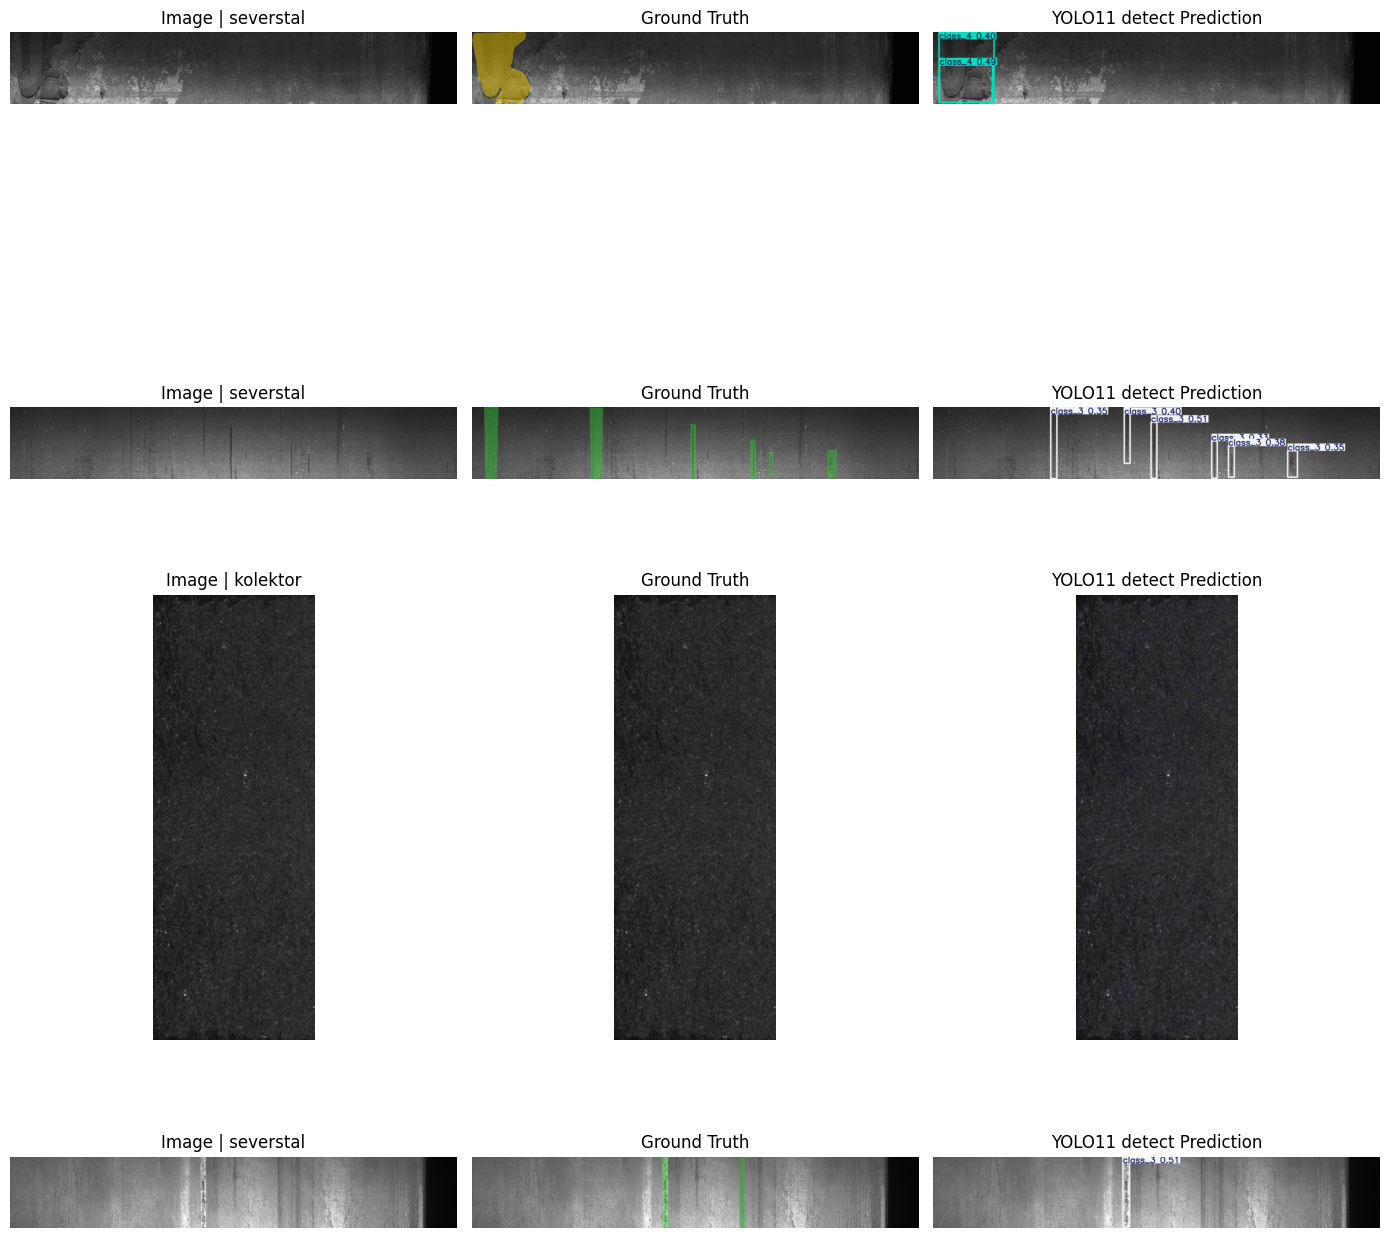

In [26]:
from utils import load_image_as_rgb, build_mask_from_record, overlay_multiclass_mask

true_random_state = random.SystemRandom().randint(0, 999999)
print('Visualization random state:', true_random_state)

viz_df = test_df.sample(frac=1, random_state=true_random_state).head(4).reset_index(drop=True)
viz_image_paths = viz_df['image_path'].tolist()
predictions = best_model.predict(viz_image_paths, imgsz=IMG_SIZE, conf=0.25, verbose=False)

fig, axes = plt.subplots(len(viz_df), 3, figsize=(14, 4 * len(viz_df)))
if len(viz_df) == 1:
    axes = [axes]

for row_idx, (_, row) in enumerate(viz_df.iterrows()):
    record = row.to_dict()
    image = load_image_as_rgb(record['image_path'])
    true_mask = build_mask_from_record(record)
    true_overlay = overlay_multiclass_mask(image, true_mask)
    pred_image = predictions[row_idx].plot()[..., ::-1]

    axes[row_idx][0].imshow(image, cmap='gray')
    axes[row_idx][0].set_title(f"Image | {record['source']}")
    axes[row_idx][1].imshow(true_overlay)
    axes[row_idx][1].set_title('Ground Truth')
    axes[row_idx][2].imshow(pred_image)
    axes[row_idx][2].set_title(f"YOLO11 {YOLO_TASK} Prediction")

    for col_idx in range(3):
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.savefig('yolo_test_predictions.png', dpi=150)
plt.show()

In [27]:
!zip -r output_folder.zip /kaggle/working/runs

  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/val/ (stored 0%)
  adding: kaggle/working/runs/detect/val/BoxPR_curve.png (deflated 10%)
  adding: kaggle/working/runs/detect/val/BoxR_curve.png (deflated 10%)
  adding: kaggle/working/runs/detect/val/val_batch0_labels.jpg (deflated 18%)
  adding: kaggle/working/runs/detect/val/BoxP_curve.png (deflated 7%)
  adding: kaggle/working/runs/detect/val/confusion_matrix.png (deflated 27%)
  adding: kaggle/working/runs/detect/val/val_batch0_pred.jpg (deflated 16%)
  adding: kaggle/working/runs/detect/val/val_batch1_labels.jpg (deflated 20%)
  adding: kaggle/working/runs/detect/val/val_batch2_pred.jpg (deflated 15%)
  adding: kaggle/working/runs/detect/val/val_batch2_labels.jpg (deflated 15%)
  adding: kaggle/working/runs/detect/val/BoxF1_curve.png (deflated 11%)
  adding: kaggle/working/runs/detect/val/val_batch1_pred.jpg (deflated 20%)
  adding: kaggle/working/runs